**ML FINAL - Mental Health Detection with Machine Learning**

This project goes over a dataset which studied mental health in subjects that admitted to a survey. The methods used for analyzing the dataset were Random Forest, CatBoost, ANN, and Logistic Regression.

In [2]:
# installs catboost
!pip install catboost
!pip install seaborn

In [3]:
# installs the right version of numpy for catboost
# !pip install numpy==1.23.5
# !pip install --force-reinstall --no-cache-dir catboost==1.2.7

In [4]:
#standard imports
import pandas as pd
import numpy as np

#processing
import shap
from sklearn.feature_extraction.text import TfidfVectorizer

#models
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier, Pool
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier

# scores
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn import metrics

# plotting
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
# only using "train" dataset, as it will let us be able to compare our models' results with the table
dataset = pd.read_csv('/content/train.csv')

print("Training Dataset:")
print(dataset.head())

print("\nNumber of Data Points:")
print(len(dataset))

Training Dataset:
   id      Name  Gender   Age           City Working Professional or Student  \
0   0  Aaradhya  Female  49.0       Ludhiana            Working Professional   
1   1     Vivan    Male  26.0       Varanasi            Working Professional   
2   2    Yuvraj    Male  33.0  Visakhapatnam                         Student   
3   3    Yuvraj    Male  22.0         Mumbai            Working Professional   
4   4      Rhea  Female  30.0         Kanpur            Working Professional   

         Profession  Academic Pressure  Work Pressure  CGPA  \
0              Chef                NaN            5.0   NaN   
1           Teacher                NaN            4.0   NaN   
2               NaN                5.0            NaN  8.97   
3           Teacher                NaN            5.0   NaN   
4  Business Analyst                NaN            1.0   NaN   

   Study Satisfaction  Job Satisfaction     Sleep Duration Dietary Habits  \
0                 NaN               2.0  More

In [6]:
#Preprocessing Data
# for future storage and comparison
accuracy_scores = []


# Define Categorical Columns
cat_cols = ["Gender", "City", "Working Professional or Student", "Profession",
            "Sleep Duration", "Dietary Habits", "Degree",
            "Have you ever had suicidal thoughts ?",
            "Family History of Mental Illness"
]

# Define Numerical Columns
num_cols = ["Age", "Academic Pressure", "Work Pressure", "CGPA",
            "Study Satisfaction", "Job Satisfaction", "Work/Study Hours",
            "Financial Stress"]

# Setting Empty Numerical Columns to 0
dataset[num_cols] = dataset[num_cols].fillna(0)

# set so there's no NaN values
dataset[cat_cols] = dataset[cat_cols].fillna("None").astype(str)

# Define Features
features = dataset.columns.tolist()
features.remove('id')
features.remove('Name')
features.remove('Depression')

# Define Label
label = dataset['Depression']

# define X and y
X = dataset[features]
y = dataset['Depression']

# One Hot Encoding
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
y_encoded = pd.get_dummies(y, columns=['Depression'],
                           drop_first=True).values.ravel()

dataset.head()

,id,Name,Gender,Age,City,Working Professional or Student,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,0,Aaradhya,Female,49.0,Ludhiana,Working Professional,Chef,0.0,5.0,0.00,0.0,2.0,More than 8 hours,Healthy,BHM,No,1.0,2.0,No,0
1,1,Vivan,Male,26.0,Varanasi,Working Professional,Teacher,0.0,4.0,0.00,0.0,3.0,Less than 5 hours,Unhealthy,LLB,Yes,7.0,3.0,No,1
2,2,Yuvraj,Male,33.0,Visakhapatnam,Student,None,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
3,3,Yuvraj,Male,22.0,Mumbai,Working Professional,Teacher,0.0,5.0,0.00,0.0,1.0,Less than 5 hours,Moderate,BBA,Yes,10.0,1.0,Yes,1
4,4,Rhea,Female,30.0,Kanpur,Working Professional,Business Analyst,0.0,1.0,0.00,0.0,1.0,5-6 hours,Unhealthy,BBA,Yes,9.0,4.0,Yes,0


In [7]:
# Logistic

# Randomly splitting the original dataset into training set and testing set:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded,
                                                    test_size=0.2,
                                                    random_state=2)

#Initialize Logistic Regression Model
logreg = LogisticRegression(solver='lbfgs', max_iter=1000)

#Train
logreg.fit(X_train, y_train)

# Predict
y_pred = logreg.predict(X_test)

#Evaluate
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {accuracy}")

Logistic Regression Accuracy: 0.9383084577114428


In [8]:
logreg.coef_

array([[-1.67345719e-01,  8.40955014e-01,  6.30809111e-01,
         4.22989977e-02, -2.54262423e-01, -5.38406580e-01,
         1.32822048e-01,  5.54385710e-01, -3.70575006e-03,
        -1.62091282e-03,  0.00000000e+00, -2.45232436e-01,
         2.81966658e-01,  0.00000000e+00, -6.67760684e-04,
         0.00000000e+00, -1.66526876e-03, -6.40489218e-06,
        -2.60112599e-04, -1.58013449e-02,  4.88126669e-03,
        -6.56092351e-02, -2.01830391e-01, -3.10899254e-02,
         3.32333623e-02, -5.83105212e-02, -7.46645224e-05,
         1.45530827e-01, -6.59942526e-05,  1.90121073e-03,
         1.04714522e-01, -6.44287471e-05,  7.76463869e-04,
         2.88896734e-03,  2.12911572e-01,  2.58950893e-02,
         7.41790319e-03, -9.45161601e-03, -1.02670296e-05,
        -5.90405585e-06, -3.29973832e-04, -3.10006914e-01,
         0.00000000e+00, -1.65439832e-04,  1.63269348e-02,
        -1.09592046e-01, -3.38961686e-02, -1.79759657e-04,
        -2.02149087e-03,  7.54186817e-03,  0.00000000e+0

In [9]:
X_train.shape

(112560, 346)

In [ ]:
# accuracy_list = cross_val_score(log_reg, X_encoded, y_encoded, cv=10, scoring='accuracy')

# print('\n\n','accuracy: ',accuracy_list)

Logistic Regression AUC: 0.9746770903288424
Confusion matrix:
[[22205   763]
 [  973  4199]]


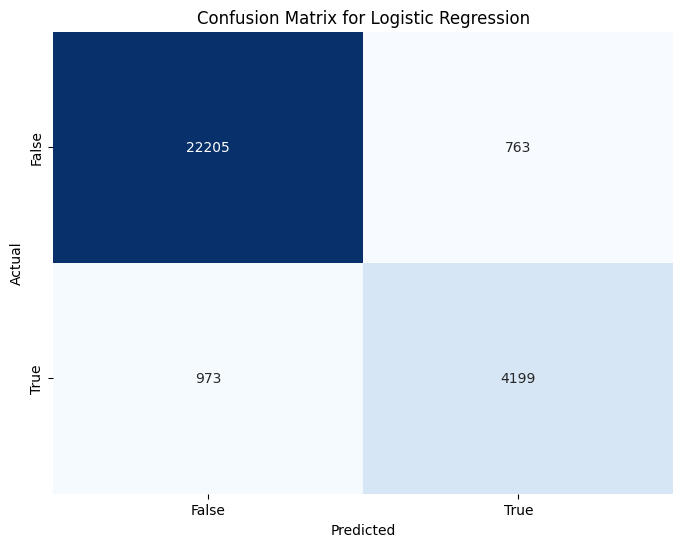

In [10]:
y_predict_prob = logreg.predict_proba(X_test)
lr_fpr, lr_tpr, thresholds = metrics.roc_curve(y_test, y_predict_prob[:, 1], pos_label=1)
lr_AUC = metrics.auc(lr_fpr, lr_tpr)
print("Logistic Regression AUC:", lr_AUC)

#Random Forest Confusion
cm_lr = metrics.confusion_matrix(y_test, y_pred)

print("Confusion matrix:")

plt.figure(figsize=(8,6))
print(cm_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=["False", "True"], yticklabels=["False", "True"], cbar=False)

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()
print()

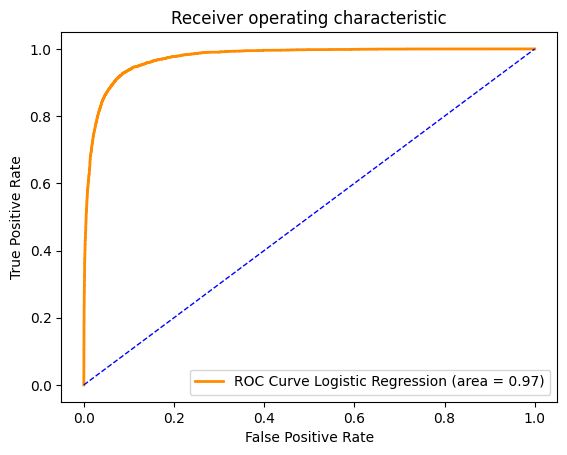

In [11]:
plt.plot(lr_fpr, lr_tpr, color='darkorange', lw=2,
         label='ROC Curve Logistic Regression (area = %0.2f)' % lr_AUC)

# Random Guess line:
plt.plot([0, 1], [0, 1], color='blue', lw=1, linestyle='--')

#Labeling the graph
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

In [ ]:
# dark

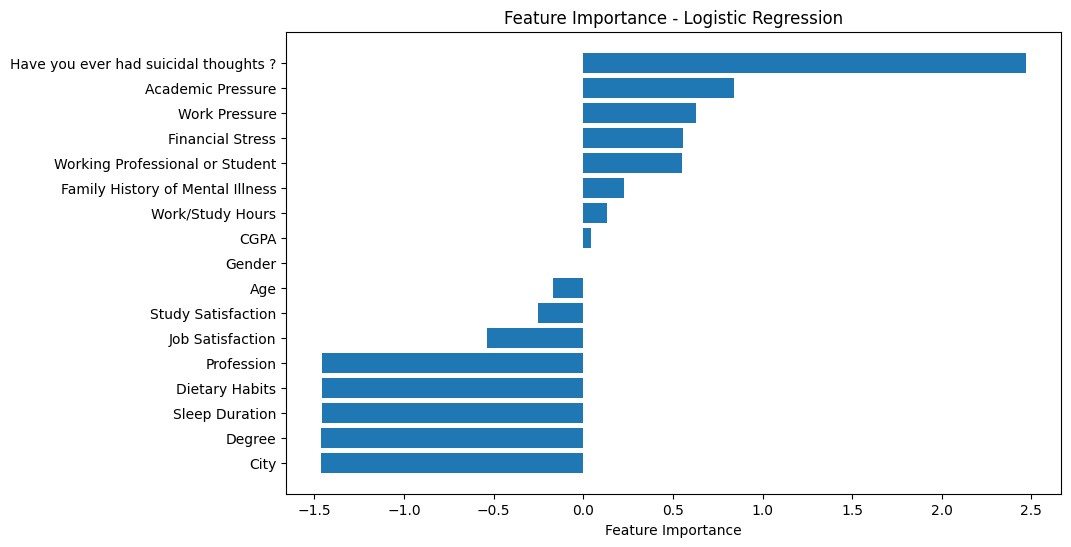

In [12]:
from collections import defaultdict
#Feature Importance
# Get feature importance values

# Coefficients and Odds Ratios
# Positive Coefficient: Indicates that an increase in the predictor variable increases the log odds of the positive class.
# Negative Coefficient: Indicates that an increase in the predictor variable decreases the log odds of the positive class.
# Odds Ratio > 1: The feature increases the odds of the outcome.
# Odds Ratio < 1: The feature decreases the odds of the outcome.
# Odds Ratio = 1: The feature does not affect the odds of the outcome.
coefficients = logreg.coef_[0]
odds_ratios = np.exp(coefficients)

importances = coefficients
feature_names = X_train.columns

# Combine into a DataFrame
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Group by prefix (before underscore)
grouped_importance = defaultdict(float)

for feature, importance in zip(feat_df['Feature'], feat_df['Importance']):
    group_key = feature.split('_')[0]  # Use full name if no underscore
    grouped_importance[group_key] += importance

# Convert to sorted DataFrame
grouped_df = pd.DataFrame(grouped_importance.items(), columns=['Feature', 'Importance'])
grouped_df = grouped_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(grouped_df['Feature'], grouped_df['Importance'])
plt.xlabel('Feature Importance')
plt.title('Feature Importance - Logistic Regression')
plt.gca().invert_yaxis()
plt.show()

# explainer = shap.TreeExplainer(my_RandomForest)
# shap_values = explainer.shap_values(X_train)

# shap.summary_plot(shap_values[1], X_train)

# # vectorizer = TfidfVectorizer(min_df=10)
# # vectorizer.fit_transform(X_train)

# # summarize the effects of all the features
# explainer = shap.Explainer(logreg, X_train) #, feature_names=vectorizer.get_feature_names_out())
# shap_values = explainer(X_test)

# # Ensure X_train is purely numeric and doesn't contain NaN or infinite values
# #X_train_numeric = X_train.select_dtypes(include=np.number).fillna(0).replace([np.inf, -np.inf], 0)
# # Instead of using X_train_numeric, use X_test which matches the shape of shap_values
# X_test_numeric = X_test.select_dtypes(include=np.number).fillna(0).replace([np.inf, -np.inf], 0)


# shap.summary_plot(shap_values, X_test_numeric) # Use the numeric X_test_numeric, which matches shap_values

In [13]:
#CatBoost

# Split the Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool = Pool(X_test, y_test, cat_features=cat_cols)

# Create and train model
catboost = CatBoostClassifier(verbose=0)
catboost.fit(train_pool)

# Predict
y_pred = catboost.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:}")

Accuracy: 0.9394456289978678


In [ ]:
# accuracy_list = cross_val_score(catboost, X, y, cv=10, scoring='accuracy')

# print('\n\n','accuracy: ',accuracy_list)

AUC Catboost:  0.9766924821813727

[[22210   776]
 [  928  4226]]


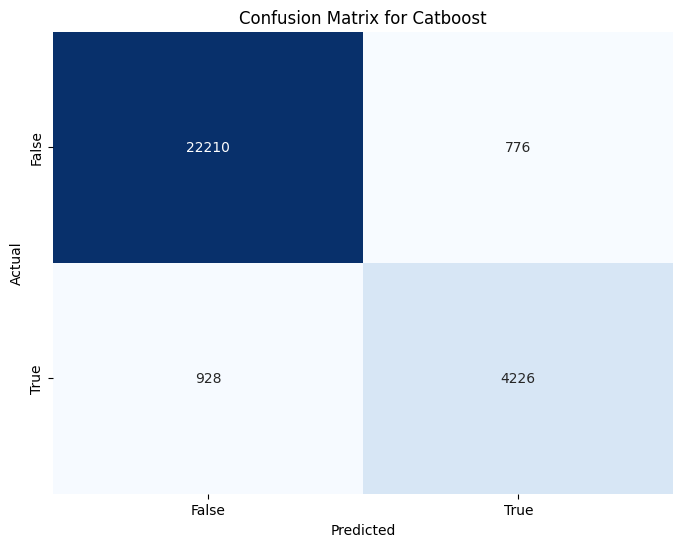

In [14]:
y_predict_prob_catboost = catboost.predict_proba(X_test)
fpr_catboost, tpr_catboost, thresholds = metrics.roc_curve(y_test, y_predict_prob_catboost[:,1], pos_label=1)
AUC_catboost = metrics.auc(fpr_catboost, tpr_catboost)
print(f"AUC Catboost:  {AUC_catboost}\n")


#Catboost Confusion
cm_catboost = metrics.confusion_matrix(y_test, y_pred)

# print("Confusion matrix:")

plt.figure(figsize=(8,6))
print(cm_catboost)
sns.heatmap(cm_catboost, annot=True, fmt='d', cmap='Blues', xticklabels=["False", "True"], yticklabels=["False", "True"], cbar=False)

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Catboost')
plt.show()
print()

Age: 31.95
Have you ever had suicidal thoughts ?: 16.62
Work Pressure: 8.44
Job Satisfaction: 7.84
Financial Stress: 7.71
Academic Pressure: 5.91
Work/Study Hours: 5.19
Dietary Habits: 3.62
Profession: 3.01
Degree: 2.58
Sleep Duration: 2.12
City: 2.04
CGPA: 1.04
Study Satisfaction: 0.87
Family History of Mental Illness: 0.56
Gender: 0.41
Working Professional or Student: 0.08


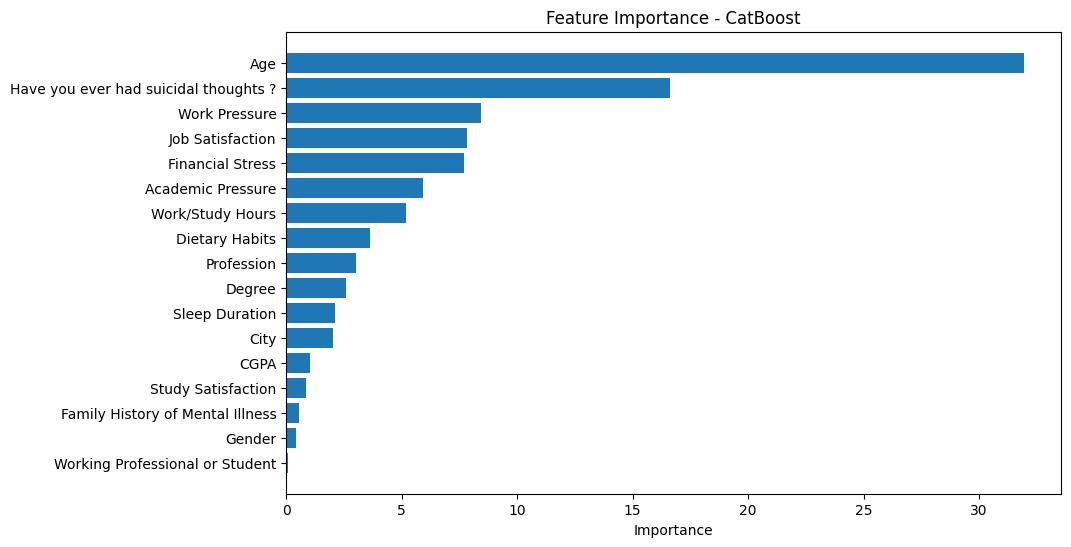

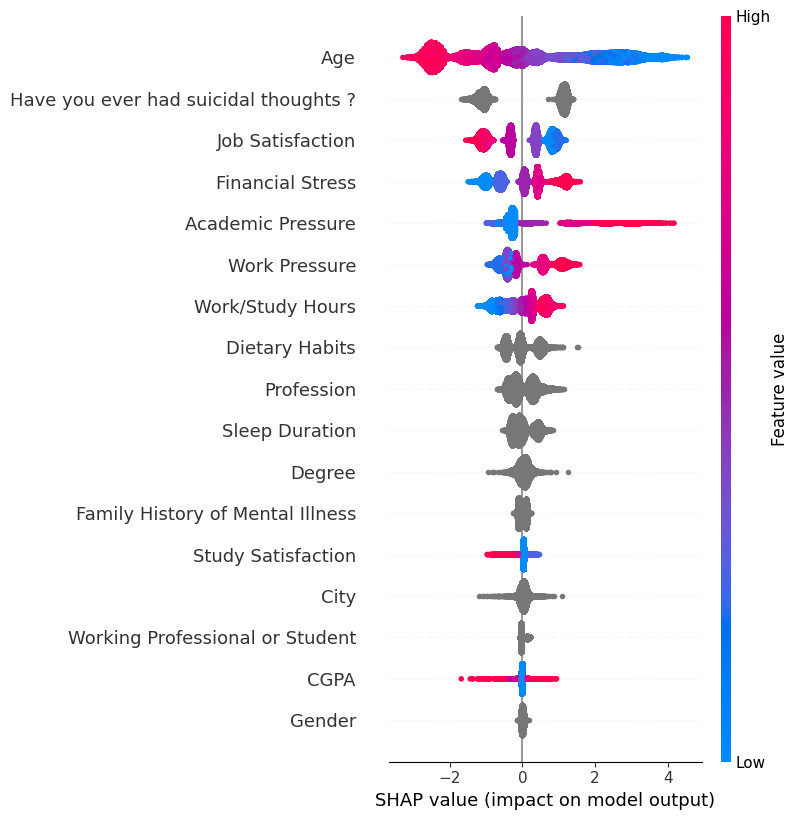

In [15]:
#Feature Importance
# Get feature importance values
feature_importances = catboost.get_feature_importance(train_pool)

# Combine names and importances and sort by importance descending
sorted_features = sorted(zip(features, feature_importances), key=lambda x: x[1], reverse=True)

# Print sorted feature importances
for name, importance in sorted_features:
    print(f'{name}: {importance:.2f}')

# Unzip into two lists for plotting
sorted_names, sorted_importances = zip(*sorted_features)

# Plot sorted feature importances
plt.figure(figsize=(10, 6))
plt.barh(sorted_names, sorted_importances)
plt.xlabel('Importance')
plt.title('Feature Importance - CatBoost')
plt.gca().invert_yaxis()
plt.show()


 # Calculate SHAP values
shap_values = catboost.get_feature_importance(type='ShapValues', data=train_pool)

# summarize the effects of all the features
explainer = shap.TreeExplainer(catboost)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

In [16]:
#ANN
# Randomly splitting the original dataset into training set and testing set:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded,
                                                    test_size=0.2,
                                                    random_state=2)

#Initialize ANN multi layer perceptron model
ann = MLPClassifier(hidden_layer_sizes=(5,5), activation= 'logistic',
                       solver='adam', alpha=1e-5, random_state=1,
                       learning_rate_init = 0.1, verbose=True, tol=0.0001)

# Training ONLY on the training set:
ann.fit(X_train, y_train)

# Testing on the testing set:
y_predict_ann = ann.predict(X_test)

# Compare the "predicted labels" with its "actual labels" to evaluate accuracy
score_ann = accuracy_score(y_test, y_predict_ann)
print('\n','accuracy: ',score_ann)

Iteration 1, loss = 0.18967245
Iteration 2, loss = 0.17279269
Iteration 3, loss = 0.17554271
Iteration 4, loss = 0.17167027
Iteration 5, loss = 0.17307146
Iteration 6, loss = 0.17628346
Iteration 7, loss = 0.17325931
Iteration 8, loss = 0.17302930
Iteration 9, loss = 0.17511273
Iteration 10, loss = 0.17426038
Iteration 11, loss = 0.17555296
Iteration 12, loss = 0.17536436
Iteration 13, loss = 0.17301573
Iteration 14, loss = 0.17545917
Iteration 15, loss = 0.17335661
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.

 accuracy:  0.9291755508173418


In [ ]:
# accuracy_list = cross_val_score(ann, X_encoded, y_encoded, cv=10, scoring='accuracy')

# print('\n\n','accuracy: ',accuracy_list)

AUC ANN:  0.9712584245796902
ANN Confusion matrix:
[[22568   400]
 [ 1593  3579]]


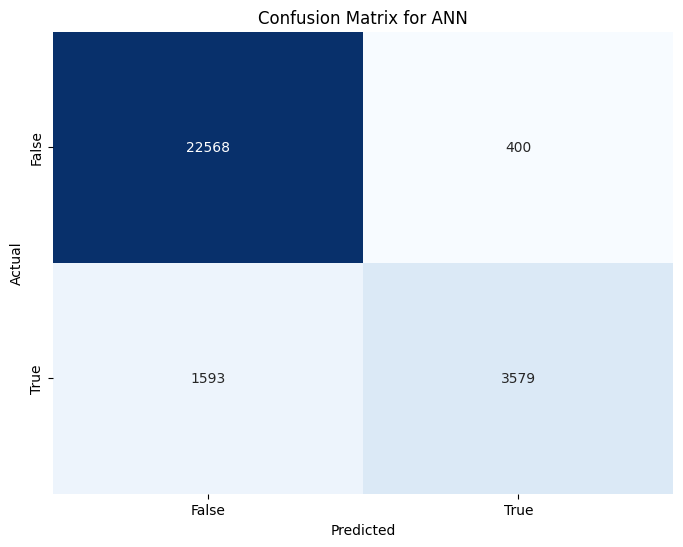

In [17]:
# ANN AUC
y_predict_prob_ann = ann.predict_proba(X_test)
fpr_ann, tpr_ann, thresholds = metrics.roc_curve(y_test, y_predict_prob_ann[:,1], pos_label=1)
AUC_ann = metrics.auc(fpr_ann, tpr_ann)
print(f"AUC ANN:  {AUC_ann}")


#ANN Confusion
cm_ann = metrics.confusion_matrix(y_test, y_predict_ann)
print("ANN Confusion matrix:")
plt.figure(figsize=(8,6))
print(cm_ann)
sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues', xticklabels=["False", "True"], yticklabels=["False", "True"], cbar=False)

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for ANN')
plt.show()

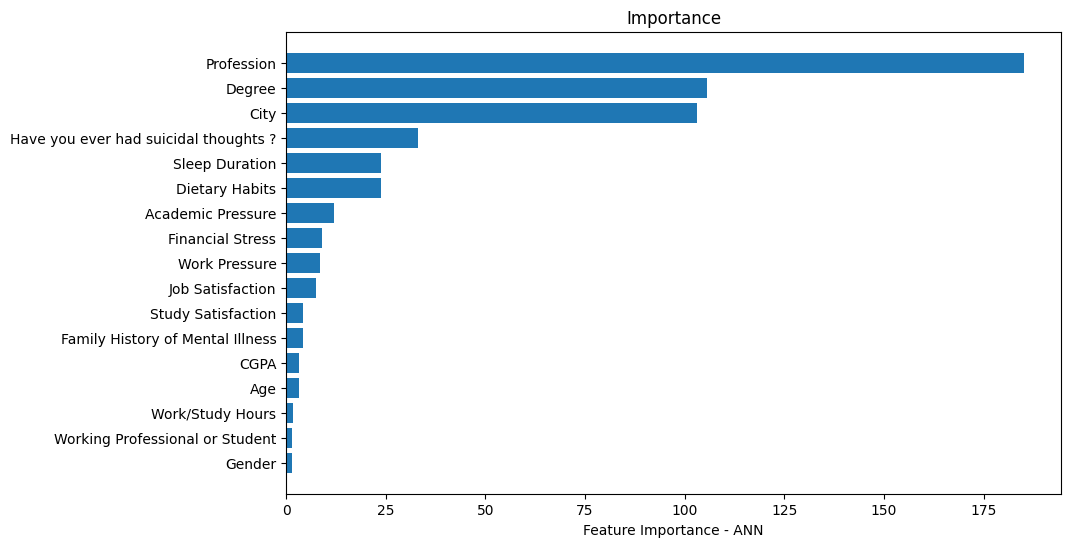

In [18]:
import pandas as pd
from collections import defaultdict

importances = np.mean(np.abs(ann.coefs_[0]), axis=1)
feature_names = X_train.columns

# Combine into a DataFrame
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Group by prefix (before underscore)
grouped_importance = defaultdict(float)

for feature, importance in zip(feat_df['Feature'], feat_df['Importance']):
    group_key = feature.split('_')[0]  # Use full name if no underscore
    grouped_importance[group_key] += importance

# Convert to sorted DataFrame
grouped_df = pd.DataFrame(grouped_importance.items(), columns=['Feature', 'Importance'])
grouped_df = grouped_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(grouped_df['Feature'], grouped_df['Importance'])
plt.xlabel('Feature Importance - ANN')
plt.title('Importance')
plt.gca().invert_yaxis()
plt.show()

# explainer = shap.TreeExplainer(ann)
# shap_values = explainer.shap_values(X_train)

# shap.summary_plot(shap_values[1], X_train)

In [19]:
AUC_ann = metrics.auc(fpr_ann, tpr_ann)
print(AUC_ann)

0.9712584245796902


In [ ]:
# THIS TAKES AN EXTREMELY LONG TIME FOR SOME REASON WHY

from sklearn.model_selection import GridSearchCV

# define a range for the "number of neurons" in the hidden layer for a network with 1 hidden layer:
neuron_number = [(i,j) for i in range(1,9) for j in range(1,9)]

# create a dictionary for grid parameter:
param_grid = dict(hidden_layer_sizes = neuron_number)
print(param_grid,'\n')

# creat the grid, and define the metric for evaluating the model:
grid = GridSearchCV(ann, param_grid, cv=10, scoring='accuracy')

# fit the grid (start the grid search):
grid.fit(X_train, y_train)

# view the results:
# print(grid.cv_results_)

# view the best results corresponding to the best structure of ANN:
print(grid.best_score_)
print(grid.best_params_)

{'hidden_layer_sizes': [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6), (3, 7), (3, 8), (4, 1), (4, 2), (4, 3), (4, 4), (4, 5), (4, 6), (4, 7), (4, 8), (5, 1), (5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (7, 1), (7, 2), (7, 3), (7, 4), (7, 5), (7, 6), (7, 7), (7, 8), (8, 1), (8, 2), (8, 3), (8, 4), (8, 5), (8, 6), (8, 7), (8, 8)]} 

Iteration 1, loss = 0.47539519
Iteration 2, loss = 0.27360294
Iteration 3, loss = 0.22028942
Iteration 4, loss = 0.21230893
Iteration 5, loss = 0.21117659
Iteration 6, loss = 0.21112271
Iteration 7, loss = 0.21116477
Iteration 8, loss = 0.20945338
Iteration 9, loss = 0.20987952
Iteration 10, loss = 0.21153460
Iteration 11, loss = 0.21636814
Iteration 12, loss = 0.21377972
Iteration 13, loss = 0.21113911
Iteration 14, loss = 0.21188877
Iteration 15, loss = 0

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Iteration 1, loss = 0.47625988
Iteration 2, loss = 0.47432056
Iteration 3, loss = 0.47437106
Iteration 4, loss = 0.47436618
Iteration 5, loss = 0.47452585
Iteration 6, loss = 0.47461662
Iteration 7, loss = 0.47442244
Iteration 8, loss = 0.47416387
Iteration 9, loss = 0.47426268
Iteration 10, loss = 0.47452274
Iteration 11, loss = 0.47459467
Iteration 12, loss = 0.47399523
Iteration 13, loss = 0.47444118
Iteration 14, loss = 0.47418736
Iteration 15, loss = 0.47432579
Iteration 16, loss = 0.27274811
Iteration 17, loss = 0.21112402
Iteration 18, loss = 0.20692290
Iteration 19, loss = 0.20361572
Iteration 20, loss = 0.20272916
Iteration 21, loss = 0.20274778
Iteration 22, loss = 0.20243191
Iteration 23, loss = 0.20435269
Iteration 24, loss = 0.20501594
Iteration 25, loss = 0.20326867
Iteration 26, loss = 0.20078747
Iteration 27, loss = 0.20038196
Iteration 28, loss = 0.20074827
Iteration 29, loss = 0.20156616
Iteration 30, loss = 0.20067825
Iteration 31, loss = 0.20249243
Iteration 32, los

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Iteration 1, loss = 0.47558844
Iteration 2, loss = 0.47398793
Iteration 3, loss = 0.47390878
Iteration 4, loss = 0.47358675
Iteration 5, loss = 0.47407860
Iteration 6, loss = 0.47409451
Iteration 7, loss = 0.47368400
Iteration 8, loss = 0.47412659


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Iteration 1, loss = 0.47548540
Iteration 2, loss = 0.47383329


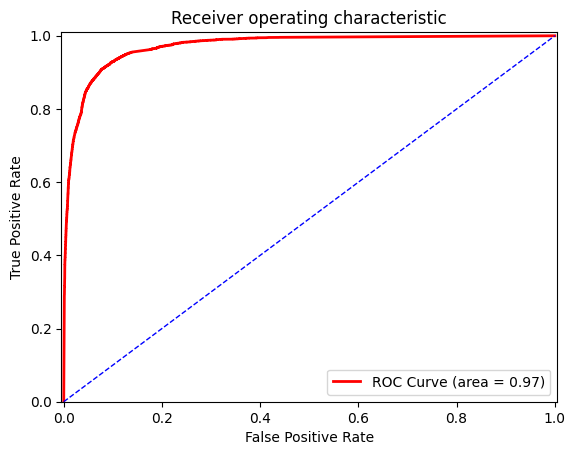

In [20]:
%matplotlib inline

plt.figure()

# Roc Curve:
plt.plot(fpr_ann, tpr_ann, color='red', lw=2,
         label='ROC Curve (area = %0.2f)' % AUC_ann)

# Random Guess line:
plt.plot([0, 1], [0, 1], color='blue', lw=1, linestyle='--')

# Defining The Range of X-Axis and Y-Axis:
plt.xlim([-0.005, 1.005])
plt.ylim([0.0, 1.01])

# Labels, Title, Legend:
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

plt.show()

In [21]:
cm_ANN = metrics.confusion_matrix(y_test, y_predict_ann)

print("Confusion matrix:")
print(cm_ANN)

Confusion matrix:
[[22568   400]
 [ 1593  3579]]


In [ ]:
#THIS TAKES A LONG TIME TOO WHY
#Feature Importance
# Get feature importance values
# explain all the predictions in the test set
explainer = shap.KernelExplainer(ann.predict_proba, X_train)
shap_values = explainer.shap_values(X_test)
shap.force_plot(shap_values, X_test)

  0%|          | 0/28140 [00:00<?, ?it/s]

In [22]:
# Random Forest

# Randomly splitting the original dataset into training set and testing set:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded,
                                                    test_size=0.2,
                                                    random_state=2)

#Initialize Random Forest Model
my_RandomForest = RandomForestClassifier(n_estimators = 29, bootstrap = True,
                                         random_state=2)

#Train
my_RandomForest.fit(X_train, y_train)

# Predict
y_pred = my_RandomForest.predict(X_test)

#Evaluate
accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Random Forest Classifier Accuracy: {accuracy}")

Random Forest Classifier Accuracy: 0.9320184790334044


In [23]:
accuracy_list = cross_val_score(my_RandomForest, X_encoded, y_encoded, cv=10, scoring='accuracy')

print('\n\n','accuracy: ',accuracy_list)



 accuracy:  [0.92992182 0.93212509 0.93191187 0.93290689 0.93162758 0.93027719
 0.93361763 0.93127221 0.93596304 0.93041933]


Random Forest AUC: 0.9666242070409403
Confusion matrix:
[[22235   733]
 [ 1180  3992]]


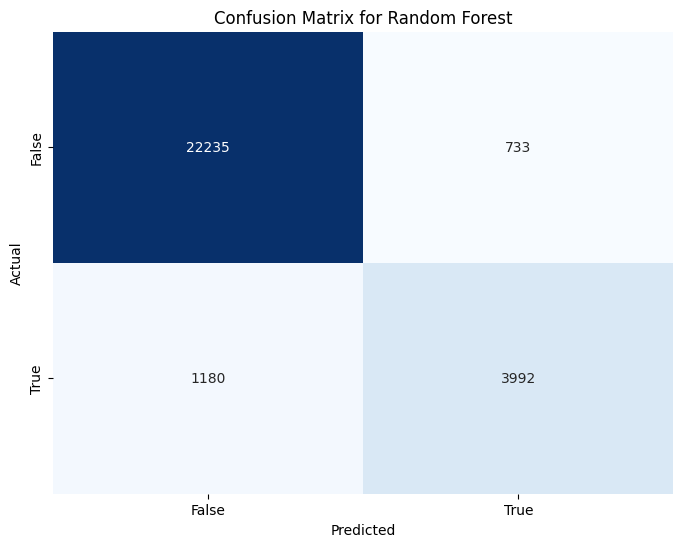

In [24]:
y_predict_prob = my_RandomForest.predict_proba(X_test)
rf_fpr, rf_tpr, thresholds = metrics.roc_curve(y_test, y_predict_prob[:, 1], pos_label=1)
rf_AUC = metrics.auc(rf_fpr, rf_tpr)
print("Random Forest AUC:", rf_AUC)

#Random Forest Confusion
cm_randomforest = metrics.confusion_matrix(y_test, y_pred)

print("Confusion matrix:")

plt.figure(figsize=(8,6))
print(cm_randomforest)
sns.heatmap(cm_randomforest, annot=True, fmt='d', cmap='Blues', xticklabels=["False", "True"], yticklabels=["False", "True"], cbar=False)

# Add labels and title
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Random Forest')
plt.show()
print()

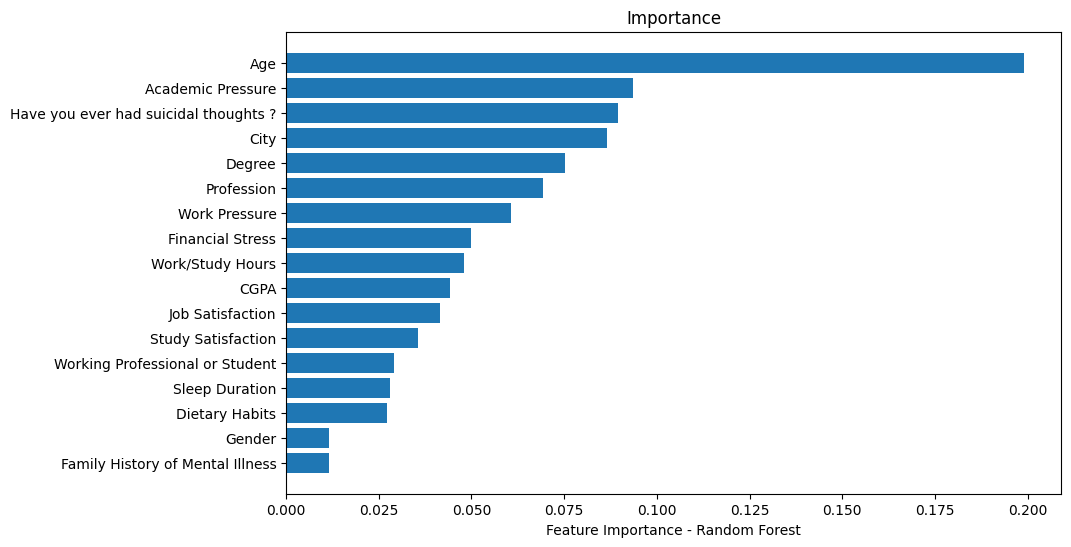

In [25]:
import pandas as pd
from collections import defaultdict

importances = my_RandomForest.feature_importances_
feature_names = X_train.columns

# Combine into a DataFrame
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Group by prefix (before underscore)
grouped_importance = defaultdict(float)

for feature, importance in zip(feat_df['Feature'], feat_df['Importance']):
    group_key = feature.split('_')[0]  # Use full name if no underscore
    grouped_importance[group_key] += importance

# Convert to sorted DataFrame
grouped_df = pd.DataFrame(grouped_importance.items(), columns=['Feature', 'Importance'])
grouped_df = grouped_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(grouped_df['Feature'], grouped_df['Importance'])
plt.xlabel('Feature Importance - Random Forest')
plt.title('Importance')
plt.gca().invert_yaxis()
plt.show()

#explainer = shap.TreeExplainer(my_RandomForest)
#shap_values = explainer.shap_values(X_train)

#shap.summary_plot(shap_values[1], X_train)

In [26]:
accuracy_df = pd.DataFrame(accuracy_scores)

# Plotting the accuracy scores
plt.figure(figsize=(8, 6))
sns.barplot(x='Model', y='Accuracy', data=accuracy_df, palette='viridis')

plt.title('Comparison of Model Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1)  # Ensure the y-axis is between 0 and 1 (accuracy range)
plt.show()

ValueError: Could not interpret value `Model` for `x`. An entry with this name does not appear in `data`.

<Figure size 800x600 with 0 Axes>

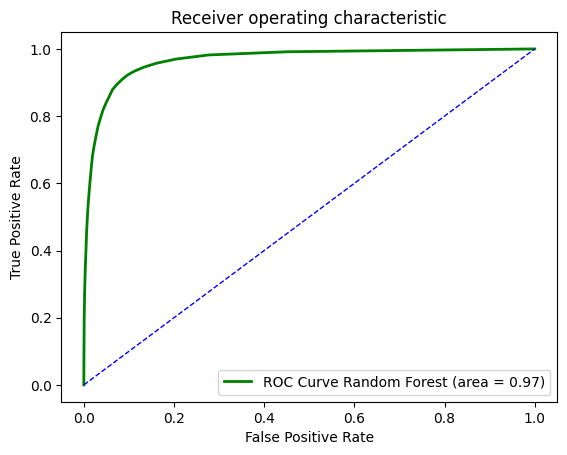

In [27]:
plt.plot(rf_fpr, rf_tpr, color='green', lw=2,
         label='ROC Curve Random Forest (area = %0.2f)' % rf_AUC)
#plt.plot(fpr_ann, tpr_ann, color='red', lw=2,
         #label='ROC Curve ANN (area = %0.2f)' % AUC_ann)
#plt.plot(fpr_catboost, tpr_catboost, color='purple', lw=2,
        # label='ROC Curve CatBoost (area = %0.2f)' % AUC_catboost)
#plt.plot(lr_svm, lr_svm, color='orange', lw=2,
         #label='ROC Curve Logistic Regression (area = %0.2f)' % lr_AUC)

# Random Guess line:
plt.plot([0, 1], [0, 1], color='blue', lw=1, linestyle='--')

#Labeling the graph
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')